# Notebook 15 — Low-TC Sector Rotation

> *Can reducing transaction costs rescue the sector rotation signal from NB13?*

**Problem:** NB13 found gross Sharpe = +0.69 but net-of-TC Sharpe = -1.74.  
TC drag = 4 positions × 0.1% × 52 rebalances = **~20.8%/yr** — kills everything.

**Two fixes tested here:**

| Variant | Description | Expected TC/yr |
|---------|-------------|----------------|
| **B1a** Monthly rebalance | Rebalance every 4 weeks | ~5.2% |
| **B1b** Threshold rebalance | Only trade when top-k changes | ~3–8% |
| **B2** Long-only | Long top-2 only (no short) | ~10.4% |

| Section | Description |
|---------|-------------|
| 1. Setup | Data + features (same pipeline as NB13) |
| 2. Baseline | Reproduce NB13 XGB-Reg weekly L/S |
| 3. B1a | Monthly rebalancing |
| 4. B1b | Threshold rebalancing |
| 5. B2 | Long-only rotation |
| 6. Comparison | Side-by-side metrics + equity curves |
| 7. Verdict | Is any variant viable? |

---
## Section 1 — Setup & Data

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

SECTORS   = ['BANK','ENERGY','ICT','COMMERCE','HEALTH','PROPERTY','FOOD']
TC        = 0.001   # 0.1% one-way
MIN_TRAIN = 156     # 3 years
FOLD_SIZE = 52      # 1 year
LONG_K    = 2
SHORT_K   = 2

# Load sector returns
sector_raw = pd.read_csv(PROC / 'sector_weekly.csv', index_col=0, parse_dates=True)
sector_raw = sector_raw[SECTORS]
sector_raw.index = sector_raw.index.normalize()

# Load macro features
macro = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
macro.index = macro.index.normalize()

MACRO_FEATS = [
    'sp500_ret_w', 'sp500_rvol_4w', 'sp500_ret_d_lag1',
    'eem_ret_d_lag1', 'oil_ret_w', 'oil_ret_d_lag1',
    'gold_ret_w', 'gold_rvol_4w',
    'dxy_ret_w', 'dxy_ret_d_lag1',
    'us_10yr_treasury_ret_w', 'us_2yr_treasury_ret_w',
    'vix_z', 'regime', 'yield_curve_slope',
    'SET_index_ret_w', 'SET_index_rvol_4w',
]
MACRO_FEATS = [f for f in MACRO_FEATS if f in macro.columns]

macro_feats = macro[MACRO_FEATS].copy()
common_dates = sector_raw.index.intersection(macro_feats.index)
sector = sector_raw.loc[common_dates]
macro_feats = macro_feats.loc[common_dates]
print(f'Sector: {sector.shape}, Macro: {macro_feats.shape}')
print(f'Date range: {common_dates[0].date()} -> {common_dates[-1].date()}')

Sector: (1322, 7), Macro: (1322, 17)
Date range: 2000-09-01 -> 2025-12-26


### Feature Engineering (Panel)

In [2]:
SECTOR_FEATS = ['mom1','mom4','mom12','mom26','rvol4','rvol12',
                'mom1_rank','mom4_rank','mom12_rank','mom1_rel','mom4_rel']
ALL_FEATS = SECTOR_FEATS + MACRO_FEATS

def build_panel(sector_df, macro_df):
    mom1   = sector_df.shift(1)
    mom4   = sector_df.shift(1).rolling(4).mean()
    mom12  = sector_df.shift(1).rolling(12).mean()
    mom26  = sector_df.shift(1).rolling(26).mean()
    rvol4  = sector_df.shift(1).rolling(4).std()
    rvol12 = sector_df.shift(1).rolling(12).std()
    mom1_rank  = mom1.rank(axis=1, pct=True) - 0.5
    mom4_rank  = mom4.rank(axis=1, pct=True) - 0.5
    mom12_rank = mom12.rank(axis=1, pct=True) - 0.5
    mom1_rel   = mom1.subtract(mom1.median(axis=1), axis=0)
    mom4_rel   = mom4.subtract(mom4.median(axis=1), axis=0)
    fwd_ret    = sector_df.shift(-1)

    records = []
    for date in sector_df.index:
        if date not in macro_df.index:
            continue
        macro_row = macro_df.loc[date]
        mkt_fwd = fwd_ret.loc[date].mean(skipna=True)
        for sec in sector_df.columns:
            row = {
                'date': date, 'sector': sec,
                'fwd_ret':    fwd_ret.loc[date, sec],
                'fwd_excess': fwd_ret.loc[date, sec] - mkt_fwd,
                'mom1':       mom1.loc[date, sec],
                'mom4':       mom4.loc[date, sec],
                'mom12':      mom12.loc[date, sec],
                'mom26':      mom26.loc[date, sec],
                'rvol4':      rvol4.loc[date, sec],
                'rvol12':     rvol12.loc[date, sec],
                'mom1_rank':  mom1_rank.loc[date, sec],
                'mom4_rank':  mom4_rank.loc[date, sec],
                'mom12_rank': mom12_rank.loc[date, sec],
                'mom1_rel':   mom1_rel.loc[date, sec],
                'mom4_rel':   mom4_rel.loc[date, sec],
            }
            for col in macro_df.columns:
                row[col] = macro_row[col] if col in macro_row.index else np.nan
            records.append(row)
    panel = pd.DataFrame(records)
    panel['date'] = pd.to_datetime(panel['date'])
    return panel.sort_values(['date','sector']).reset_index(drop=True)

panel = build_panel(sector, macro_feats)
panel_clean = panel.dropna(subset=['fwd_excess']).copy()
dates_all = sorted(panel_clean['date'].unique())
print(f'Panel: {len(panel_clean)} rows, {len(dates_all)} dates, {len(ALL_FEATS)} features')

Panel: 9247 rows, 1321 dates, 28 features


---
## Section 2 — Baseline: Weekly Rebalancing L/S (NB13)

In [3]:
def make_xgb():
    return XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.6,
        min_child_weight=10, reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, verbosity=0, n_jobs=1
    )

def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1+r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

def ic_summary(ic_series):
    ics = ic_series.dropna()
    if len(ics) < 10: return {}
    t, p = ttest_1samp(ics, 0)
    icir = ics.mean() / ics.std() * np.sqrt(len(ics)) if ics.std() > 0 else np.nan
    return {'ic_mean':ics.mean(),'icir':icir,'ic_pos':(ics>0).mean(),'p':p}

# ── Walk-forward: weekly L/S (baseline) ──
def wf_weekly_ls(panel_df, features, long_k=2, short_k=2):
    dates = sorted(panel_df['date'].unique())
    n = len(dates)
    records = []
    t = MIN_TRAIN
    while t + FOLD_SIZE <= n:
        train = panel_df[panel_df['date'].isin(dates[:t])]
        test  = panel_df[panel_df['date'].isin(dates[t:t+FOLD_SIZE])]
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        m = make_xgb(); m.fit(Xtr, train['fwd_excess'].values)
        for date, grp in test.groupby('date'):
            if len(grp) < 3: continue
            Xte = grp[features].fillna(medians).fillna(0.).values.astype(float)
            grp = grp.copy()
            grp['pred'] = m.predict(Xte)
            s = grp.sort_values('pred', ascending=False)
            long_r  = s.head(long_k)['fwd_ret'].mean()
            short_r = s.tail(short_k)['fwd_ret'].mean()
            port_r  = (long_r - short_r) / 2
            ic = float(spearmanr(grp['pred'], grp['fwd_excess'])[0]) if len(grp)>=4 else np.nan
            records.append({'date':date,'gross_ret':port_r,
                            'net_ret':port_r - (long_k+short_k)*TC,
                            'mkt_ret':grp['fwd_ret'].mean(), 'ic':ic})
        t += FOLD_SIZE
    return pd.DataFrame(records).set_index('date').sort_index()

print('Running baseline (weekly L/S)...')
res_base = wf_weekly_ls(panel_clean, ALL_FEATS)
m_base = risk_metrics(res_base['net_ret'])
ic_base = ic_summary(res_base['ic'])
print(f'Baseline  gross Sharpe: {risk_metrics(res_base["gross_ret"])["sharpe"]:+.3f}')
print(f'Baseline  net   Sharpe: {m_base["sharpe"]:+.3f}  (IC mean={ic_base["ic_mean"]:+.4f}, p={ic_base["p"]:.4f})')

Running baseline (weekly L/S)...


Baseline  gross Sharpe: +0.282
Baseline  net   Sharpe: -1.758  (IC mean=+0.0262, p=0.0343)


---
## Section 3 — B1a: Monthly Rebalancing

Rebalance every **4 weeks** instead of every week.  
TC per year: 4 positions × 0.1% × 13 rebalances = **5.2%/yr** (was 20.8%).

In [4]:
def wf_monthly_ls(panel_df, features, rebal_freq=4, long_k=2, short_k=2):
    """Walk-forward L/S that only rebalances every rebal_freq weeks."""
    dates = sorted(panel_df['date'].unique())
    n = len(dates)
    records = []
    t = MIN_TRAIN
    while t + FOLD_SIZE <= n:
        train = panel_df[panel_df['date'].isin(dates[:t])]
        test_dates = dates[t:t+FOLD_SIZE]
        test  = panel_df[panel_df['date'].isin(test_dates)]
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        m = make_xgb(); m.fit(Xtr, train['fwd_excess'].values)

        current_longs  = []
        current_shorts = []
        for i, date in enumerate(test_dates):
            grp = test[test['date'] == date]
            if len(grp) < 3: continue
            Xte = grp[features].fillna(medians).fillna(0.).values.astype(float)
            grp = grp.copy(); grp['pred'] = m.predict(Xte)
            s = grp.sort_values('pred', ascending=False)

            rebalanced = (i % rebal_freq == 0) or (not current_longs)
            if rebalanced:
                current_longs  = s.head(long_k)['sector'].tolist()
                current_shorts = s.tail(short_k)['sector'].tolist()
                tc_cost = (long_k + short_k) * TC
            else:
                tc_cost = 0.0

            long_r  = grp[grp['sector'].isin(current_longs)]['fwd_ret'].mean()
            short_r = grp[grp['sector'].isin(current_shorts)]['fwd_ret'].mean()
            port_r  = (long_r - short_r) / 2
            ic = float(spearmanr(grp['pred'], grp['fwd_excess'])[0]) if len(grp)>=4 else np.nan
            records.append({'date':date,'gross_ret':port_r,
                            'net_ret':port_r - tc_cost,
                            'mkt_ret':grp['fwd_ret'].mean(),'ic':ic,
                            'rebalanced':rebalanced})
        t += FOLD_SIZE
    return pd.DataFrame(records).set_index('date').sort_index()

print('Running B1a (monthly rebalancing, every 4w)...')
res_b1a = wf_monthly_ls(panel_clean, ALL_FEATS, rebal_freq=4)
m_b1a = risk_metrics(res_b1a['net_ret'])
ic_b1a = ic_summary(res_b1a['ic'])
rebal_freq_b1a = res_b1a['rebalanced'].mean()
print(f'B1a rebalance rate: {rebal_freq_b1a:.1%} of weeks')
print(f'B1a  gross Sharpe: {risk_metrics(res_b1a["gross_ret"])["sharpe"]:+.3f}')
print(f'B1a  net   Sharpe: {m_b1a["sharpe"]:+.3f}  (IC mean={ic_b1a["ic_mean"]:+.4f}, p={ic_b1a["p"]:.4f})')

# Also test 8-week (bi-monthly) rebalancing
print('Running B1a-8w (bi-monthly rebalancing, every 8w)...')
res_b1a_8 = wf_monthly_ls(panel_clean, ALL_FEATS, rebal_freq=8)
m_b1a_8 = risk_metrics(res_b1a_8['net_ret'])
print(f'B1a-8w gross Sharpe: {risk_metrics(res_b1a_8["gross_ret"])["sharpe"]:+.3f}')
print(f'B1a-8w net   Sharpe: {m_b1a_8["sharpe"]:+.3f}')

Running B1a (monthly rebalancing, every 4w)...


B1a rebalance rate: 25.0% of weeks
B1a  gross Sharpe: +0.352
B1a  net   Sharpe: -0.236  (IC mean=+0.0262, p=0.0343)
Running B1a-8w (bi-monthly rebalancing, every 8w)...


B1a-8w gross Sharpe: +0.478
B1a-8w net   Sharpe: +0.165


---
## Section 4 — B1b: Threshold Rebalancing

Only rebalance when the **top-k set actually changes** (at least 1 new sector enters).  
This naturally reduces turnover when the model is confident/stable.

In [5]:
def wf_threshold_ls(panel_df, features, long_k=2, short_k=2, min_change=1):
    """
    Walk-forward L/S that only trades when top-k positions change.
    min_change: minimum number of sectors that must enter/exit to trigger rebalance.
    """
    dates = sorted(panel_df['date'].unique())
    n = len(dates)
    records = []
    t = MIN_TRAIN
    while t + FOLD_SIZE <= n:
        train = panel_df[panel_df['date'].isin(dates[:t])]
        test_dates = dates[t:t+FOLD_SIZE]
        test  = panel_df[panel_df['date'].isin(test_dates)]
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        m = make_xgb(); m.fit(Xtr, train['fwd_excess'].values)

        current_longs  = set()
        current_shorts = set()
        for date in test_dates:
            grp = test[test['date'] == date]
            if len(grp) < 3: continue
            Xte = grp[features].fillna(medians).fillna(0.).values.astype(float)
            grp = grp.copy(); grp['pred'] = m.predict(Xte)
            s = grp.sort_values('pred', ascending=False)
            new_longs  = set(s.head(long_k)['sector'].tolist())
            new_shorts = set(s.tail(short_k)['sector'].tolist())

            # Count position changes
            long_changes  = len(new_longs  - current_longs)
            short_changes = len(new_shorts - current_shorts)
            total_changes = long_changes + short_changes

            rebalanced = (total_changes >= min_change) or (not current_longs)
            if rebalanced:
                current_longs  = new_longs
                current_shorts = new_shorts
                tc_cost = (long_changes + short_changes) * TC  # pay TC only on changes
            else:
                tc_cost = 0.0

            long_r  = grp[grp['sector'].isin(current_longs)]['fwd_ret'].mean()
            short_r = grp[grp['sector'].isin(current_shorts)]['fwd_ret'].mean()
            port_r  = (long_r - short_r) / 2
            ic = float(spearmanr(grp['pred'], grp['fwd_excess'])[0]) if len(grp)>=4 else np.nan
            records.append({'date':date,'gross_ret':port_r,
                            'net_ret':port_r - tc_cost,
                            'mkt_ret':grp['fwd_ret'].mean(),'ic':ic,
                            'rebalanced':rebalanced,
                            'tc_cost':tc_cost})
        t += FOLD_SIZE
    return pd.DataFrame(records).set_index('date').sort_index()

print('Running B1b (threshold rebalancing)...')
res_b1b = wf_threshold_ls(panel_clean, ALL_FEATS, min_change=1)
m_b1b = risk_metrics(res_b1b['net_ret'])
ic_b1b = ic_summary(res_b1b['ic'])
rebal_rate_b1b = res_b1b['rebalanced'].mean()
avg_tc_b1b = res_b1b['tc_cost'].mean() * 52  # annualised
print(f'B1b rebalance rate: {rebal_rate_b1b:.1%} of weeks')
print(f'B1b avg TC/yr:      {avg_tc_b1b:.2%}')
print(f'B1b  gross Sharpe: {risk_metrics(res_b1b["gross_ret"])["sharpe"]:+.3f}')
print(f'B1b  net   Sharpe: {m_b1b["sharpe"]:+.3f}  (IC mean={ic_b1b["ic_mean"]:+.4f}, p={ic_b1b["p"]:.4f})')

Running B1b (threshold rebalancing)...


B1b rebalance rate: 92.8% of weeks
B1b avg TC/yr:      9.74%
B1b  gross Sharpe: +0.282
B1b  net   Sharpe: -0.724  (IC mean=+0.0262, p=0.0343)


---
## Section 5 — B2: Long-Only Sector Rotation

Hold the **top-2 sectors** (equal weight), no short side.  
TC per year: 2 positions × 0.1% × 52 = **10.4%/yr**.  
Benchmark: equal-weight all-sector portfolio (SET proxy).

Two sub-variants:
- **B2-weekly**: rebalance top-2 every week
- **B2-monthly**: rebalance top-2 every 4 weeks

In [6]:
def wf_longonly(panel_df, features, long_k=2, rebal_freq=1):
    """
    Walk-forward long-only: hold top-k sectors.
    Returns: port_ret (long-only), bench_ret (equal-weight all sectors).
    """
    dates = sorted(panel_df['date'].unique())
    n = len(dates)
    records = []
    t = MIN_TRAIN
    while t + FOLD_SIZE <= n:
        train = panel_df[panel_df['date'].isin(dates[:t])]
        test_dates = dates[t:t+FOLD_SIZE]
        test  = panel_df[panel_df['date'].isin(test_dates)]
        medians = train[features].median()
        Xtr = train[features].fillna(medians).fillna(0.).values.astype(float)
        m = make_xgb(); m.fit(Xtr, train['fwd_excess'].values)

        current_longs = []
        prev_longs    = []
        for i, date in enumerate(test_dates):
            grp = test[test['date'] == date]
            if len(grp) < 3: continue
            Xte = grp[features].fillna(medians).fillna(0.).values.astype(float)
            grp = grp.copy(); grp['pred'] = m.predict(Xte)
            s = grp.sort_values('pred', ascending=False)

            rebalanced = (i % rebal_freq == 0) or (not current_longs)
            if rebalanced:
                prev_longs    = current_longs[:]
                current_longs = s.head(long_k)['sector'].tolist()
                # TC: only on sectors that changed
                changed = len(set(current_longs) - set(prev_longs)) if prev_longs else long_k
                tc_cost = changed * TC
            else:
                tc_cost = 0.0

            long_r  = grp[grp['sector'].isin(current_longs)]['fwd_ret'].mean()
            bench_r = grp['fwd_ret'].mean()   # equal-weight all sectors
            ic = float(spearmanr(grp['pred'], grp['fwd_excess'])[0]) if len(grp)>=4 else np.nan
            records.append({'date':date,
                            'port_ret':long_r,
                            'gross_ret':long_r - bench_r,  # excess vs benchmark
                            'net_ret':(long_r - bench_r) - tc_cost,
                            'bench_ret':bench_r,'ic':ic,
                            'rebalanced':rebalanced,'tc_cost':tc_cost})
        t += FOLD_SIZE
    return pd.DataFrame(records).set_index('date').sort_index()

print('Running B2-weekly (long-only, weekly rebalance)...')
res_b2w = wf_longonly(panel_clean, ALL_FEATS, long_k=2, rebal_freq=1)
m_b2w_port  = risk_metrics(res_b2w['port_ret'])  # absolute return
m_b2w_bench = risk_metrics(res_b2w['bench_ret'])
m_b2w_net   = risk_metrics(res_b2w['net_ret'])   # excess vs bench net of TC
print(f'B2-weekly  port  Sharpe (abs):   {m_b2w_port["sharpe"]:+.3f}')
print(f'B2-weekly  bench Sharpe (EW):    {m_b2w_bench["sharpe"]:+.3f}')
print(f'B2-weekly  excess Sharpe (net):  {m_b2w_net["sharpe"]:+.3f}')

print('Running B2-monthly (long-only, monthly rebalance)...')
res_b2m = wf_longonly(panel_clean, ALL_FEATS, long_k=2, rebal_freq=4)
m_b2m_port = risk_metrics(res_b2m['port_ret'])
m_b2m_net  = risk_metrics(res_b2m['net_ret'])
avg_tc_b2m = res_b2m['tc_cost'].mean() * 52
print(f'B2-monthly port  Sharpe (abs):   {m_b2m_port["sharpe"]:+.3f}')
print(f'B2-monthly excess Sharpe (net):  {m_b2m_net["sharpe"]:+.3f}')
print(f'B2-monthly avg TC/yr:            {avg_tc_b2m:.2%}')

Running B2-weekly (long-only, weekly rebalance)...


B2-weekly  port  Sharpe (abs):   +0.793
B2-weekly  bench Sharpe (EW):    +0.698
B2-weekly  excess Sharpe (net):  -0.442
Running B2-monthly (long-only, monthly rebalance)...


B2-monthly port  Sharpe (abs):   +0.780
B2-monthly excess Sharpe (net):  -0.321
B2-monthly avg TC/yr:            1.63%


---
## Section 6 — Comparison: All Variants

Side-by-side metrics and equity curves for all strategies.

In [7]:
# ── Summary table ──
bnh = res_base['mkt_ret']  # equal-weight benchmark
m_bnh = risk_metrics(bnh)

rows = [
    ('NB13 Baseline (weekly L/S)',  res_base['gross_ret'],  res_base['net_ret'],  'L/S'),
    ('B1a Monthly (4w L/S)',        res_b1a['gross_ret'],   res_b1a['net_ret'],   'L/S'),
    ('B1a Bi-monthly (8w L/S)',     res_b1a_8['gross_ret'], res_b1a_8['net_ret'], 'L/S'),
    ('B1b Threshold (L/S)',         res_b1b['gross_ret'],   res_b1b['net_ret'],   'L/S'),
    ('B2 Long-only weekly',         res_b2w['port_ret'],    res_b2w['port_ret'] - res_b2w['tc_cost'], 'LO'),
    ('B2 Long-only monthly',        res_b2m['port_ret'],    res_b2m['port_ret'] - res_b2m['tc_cost'], 'LO'),
    ('Equal-Weight B&H',            bnh,                    bnh,                  'BNH'),
]

print(f'{"Strategy":<32} {"Type":>4} {"AnnRet(gross)":>14} {"AnnRet(net)":>12} {"Sharpe(net)":>12} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 96)
for name, gross, net, typ in rows:
    mg = risk_metrics(gross)
    mn = risk_metrics(net)
    if not mn: continue
    flag = ' ✓' if mn['sharpe'] > 0.3 else ''
    print(f'{name:<32} {typ:>4} {mg["ann_ret"]:>13.2%} {mn["ann_ret"]:>12.2%} '
          f'{mn["sharpe"]:>12.2f} {mn["max_dd"]:>8.1%} {mn["win_rate"]:>8.1%}{flag}')

Strategy                         Type  AnnRet(gross)  AnnRet(net)  Sharpe(net)    MaxDD  WinRate
------------------------------------------------------------------------------------------------
NB13 Baseline (weekly L/S)        L/S         2.67%      -16.64%        -1.76   -98.3%    36.8%
B1a Monthly (4w L/S)              L/S         3.12%       -2.12%        -0.24   -47.5%    50.2%
B1a Bi-monthly (8w L/S)           L/S         4.42%        1.54%         0.17   -32.0%    49.4%
B1b Threshold (L/S)               L/S         2.67%       -6.86%        -0.72   -80.6%    45.7%
B2 Long-only weekly                LO        17.22%       11.99%         0.55   -60.4%    54.0% ✓
B2 Long-only monthly               LO        16.96%       15.08%         0.69   -64.1%    55.3% ✓
Equal-Weight B&H                  BNH        17.57%       17.57%         0.70   -53.5%    58.0% ✓


In [8]:
# ── IC summary table ──
ic_rows = [
    ('NB13 Baseline',       res_base['ic']),
    ('B1a Monthly',         res_b1a['ic']),
    ('B1b Threshold',       res_b1b['ic']),
    ('B2 Long-only weekly', res_b2w['ic']),
    ('B2 Long-only monthly',res_b2m['ic']),
]
print(f'\n{"Strategy":<28} {"IC mean":>9} {"ICIR":>8} {"IC+%":>7} {"p":>8}')
print('-' * 65)
for name, ic_ser in ic_rows:
    s = ic_summary(ic_ser)
    if not s: continue
    sig = ' *' if s['p'] < 0.05 else ''
    print(f'{name:<28} {s["ic_mean"]:>+9.4f} {s["icir"]:>8.3f} {s["ic_pos"]:>7.1%} {s["p"]:>8.4f}{sig}')


Strategy                       IC mean     ICIR    IC+%        p
-----------------------------------------------------------------
NB13 Baseline                  +0.0262    2.118   51.1%   0.0343 *
B1a Monthly                    +0.0262    2.118   51.1%   0.0343 *
B1b Threshold                  +0.0262    2.118   51.1%   0.0343 *
B2 Long-only weekly            +0.0262    2.118   51.1%   0.0343 *
B2 Long-only monthly           +0.0262    2.118   51.1%   0.0343 *


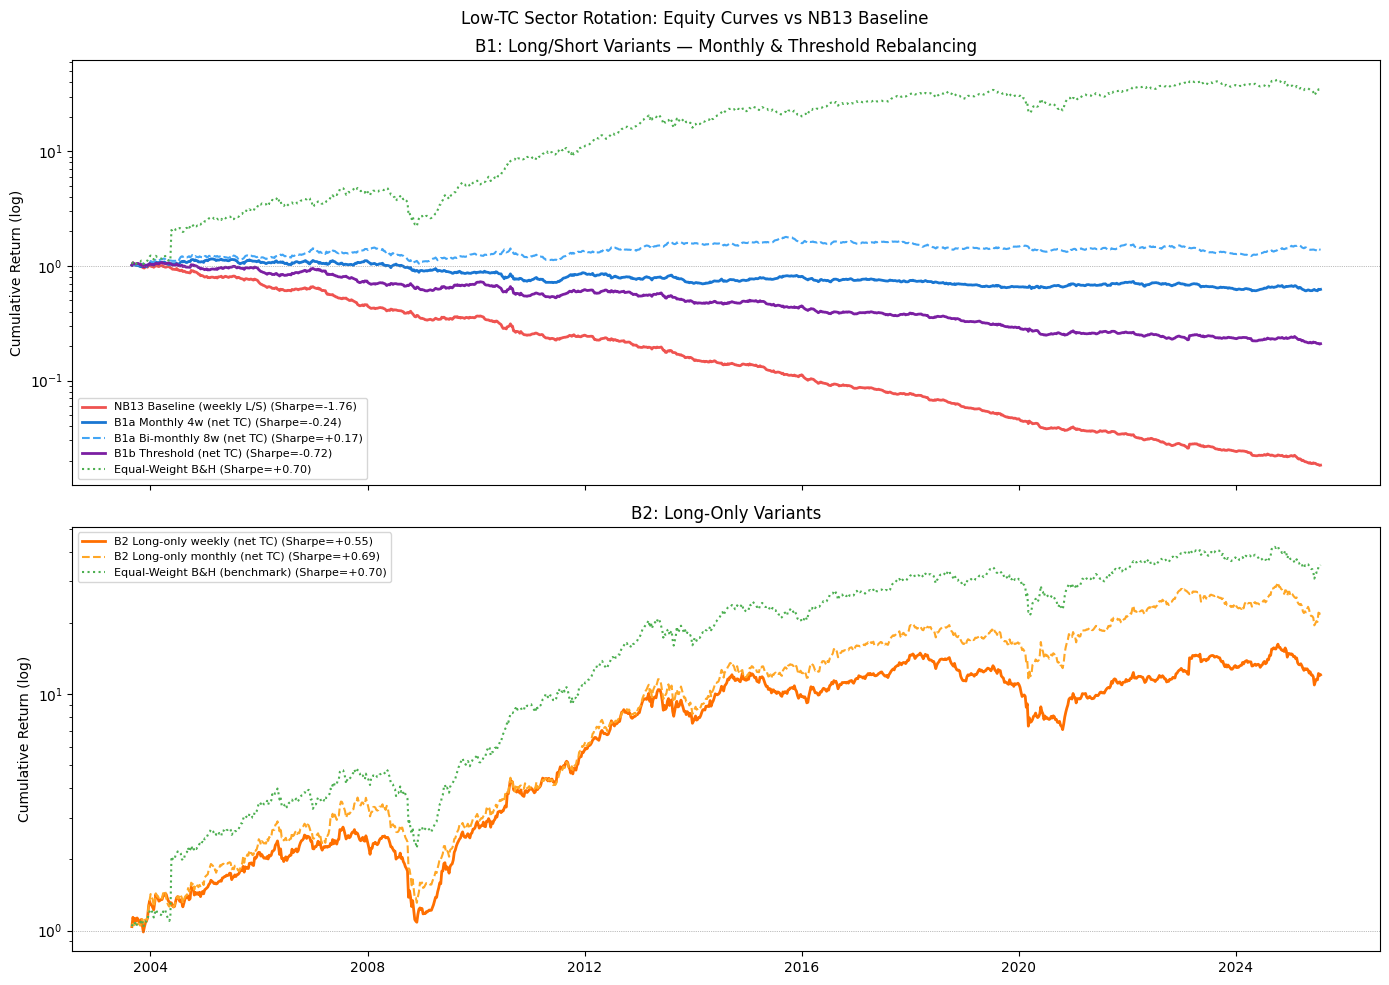

Saved: figs/low_tc_equity.png


In [9]:
# ── Equity curves ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Low-TC Sector Rotation: Equity Curves vs NB13 Baseline', fontsize=12)

# Top: L/S variants
ax = axes[0]
plot_ls = [
    (res_base['net_ret'],  'NB13 Baseline (weekly L/S)', '#EF5350', '-',  2.0),
    (res_b1a['net_ret'],   'B1a Monthly 4w (net TC)',    '#1976D2', '-',  2.0),
    (res_b1a_8['net_ret'], 'B1a Bi-monthly 8w (net TC)', '#42A5F5', '--', 1.5),
    (res_b1b['net_ret'],   'B1b Threshold (net TC)',     '#7B1FA2', '-',  2.0),
    (bnh,                  'Equal-Weight B&H',           '#4CAF50', ':',  1.5),
]
for rets, lbl, col, ls, lw in plot_ls:
    cum = (1 + rets.dropna()).cumprod()
    m   = risk_metrics(rets)
    ax.plot(cum, lw=lw, ls=ls, color=col, label=f'{lbl} (Sharpe={m["sharpe"]:+.2f})')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.set_title('B1: Long/Short Variants — Monthly & Threshold Rebalancing')
ax.legend(fontsize=8, loc='lower left')

# Bottom: long-only variants
ax2 = axes[1]
lo_rets_w = res_b2w['port_ret'] - res_b2w['tc_cost']
lo_rets_m = res_b2m['port_ret'] - res_b2m['tc_cost']
bench_b2  = res_b2w['bench_ret']
for rets, lbl, col, ls, lw in [
    (lo_rets_w,  'B2 Long-only weekly (net TC)',  '#FF6F00', '-',  2.0),
    (lo_rets_m,  'B2 Long-only monthly (net TC)', '#FFA726', '--', 1.5),
    (bench_b2,   'Equal-Weight B&H (benchmark)',  '#4CAF50', ':',  1.5),
]:
    cum = (1 + rets.dropna()).cumprod()
    m   = risk_metrics(rets)
    ax2.plot(cum, lw=lw, ls=ls, color=col, label=f'{lbl} (Sharpe={m["sharpe"]:+.2f})')
ax2.axhline(1.0, color='gray', lw=0.5, ls=':')
ax2.set_yscale('log')
ax2.set_ylabel('Cumulative Return (log)')
ax2.set_title('B2: Long-Only Variants')
ax2.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(FIGS / 'low_tc_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/low_tc_equity.png')

In [10]:
# ── TC breakdown ──
print('TC Analysis:')
print(f'{"Strategy":<32} {"TC/yr (approx)":>16} {"Rebal rate":>12}')
print('-' * 62)
print(f'{"NB13 Baseline (weekly L/S)":<32} {(LONG_K+SHORT_K)*TC*52:>16.2%} {1.0:>12.1%}')
print(f'{"B1a Monthly (4w)":<32} {(LONG_K+SHORT_K)*TC*13:>16.2%} {res_b1a["rebalanced"].mean():>12.1%}')
print(f'{"B1a Bi-monthly (8w)":<32} {(LONG_K+SHORT_K)*TC*6.5:>16.2%} {res_b1a_8["rebalanced"].mean():>12.1%}')
print(f'{"B1b Threshold":<32} {res_b1b["tc_cost"].mean()*52:>16.2%} {res_b1b["rebalanced"].mean():>12.1%}')
print(f'{"B2 Long-only weekly":<32} {res_b2w["tc_cost"].mean()*52:>16.2%} {res_b2w["rebalanced"].mean():>12.1%}')
print(f'{"B2 Long-only monthly":<32} {res_b2m["tc_cost"].mean()*52:>16.2%} {res_b2m["rebalanced"].mean():>12.1%}')

TC Analysis:
Strategy                           TC/yr (approx)   Rebal rate
--------------------------------------------------------------
NB13 Baseline (weekly L/S)                 20.80%       100.0%
B1a Monthly (4w)                            5.20%        25.0%
B1a Bi-monthly (8w)                         2.60%        13.5%
B1b Threshold                               9.74%        92.8%
B2 Long-only weekly                         4.58%       100.0%
B2 Long-only monthly                        1.63%        25.0%


---
## Section 7 — Verdict

In [11]:
# ── Score each variant ──
def score_variant(net_ret, ic_ser, label):
    m  = risk_metrics(net_ret)
    ic = ic_summary(ic_ser)
    if not m or not ic:
        return
    ev = [
        ('IC mean > 0.03',           ic['ic_mean'],    0.03,  ic['ic_mean'] > 0.03),
        ('IC t-test p < 0.05',       ic['p'],          0.05,  ic['p'] < 0.05),
        ('ICIR > 0.5',               ic['icir'],       0.5,   ic['icir'] > 0.5),
        ('Sharpe (net TC) > 0',      m['sharpe'],      0,     m['sharpe'] > 0),
        ('Sharpe (net TC) > 0.3',    m['sharpe'],      0.3,   m['sharpe'] > 0.3),
        ('Annual return net > 0%',   m['ann_ret'],     0,     m['ann_ret'] > 0),
        ('Max DD > -40%',            m['max_dd'],     -0.4,   m['max_dd'] > -0.4),
        ('Win rate > 50%',           m['win_rate'],    0.5,   m['win_rate'] > 0.5),
    ]
    score = sum(1 for *_, p in ev if p)
    print(f'\n{label}  (Score: {score}/{len(ev)})')
    print('-' * 55)
    for desc, val, thr, passed in ev:
        mark = '[+]' if passed else '[-]'
        if isinstance(val, float) and abs(val) < 2:
            print(f'  {mark} {desc:<34} {val:>+.4f}  > {thr}')
        else:
            print(f'  {mark} {desc:<34} {val:>+.1%}  > {thr:.0%}')
    verdict = 'VIABLE' if score >= 5 else 'BORDERLINE' if score >= 3 else 'NOT VIABLE'
    print(f'  => {verdict}')
    return score

print('=' * 60)
print('LOW-TC SECTOR ROTATION VERDICT')
print('=' * 60)
scores = {}
for name, net, ic_s in [
    ('NB13 Baseline (weekly L/S)',  res_base['net_ret'],  res_base['ic']),
    ('B1a Monthly (4w L/S)',        res_b1a['net_ret'],   res_b1a['ic']),
    ('B1a Bi-monthly (8w L/S)',     res_b1a_8['net_ret'], res_b1a_8['ic']),
    ('B1b Threshold L/S',          res_b1b['net_ret'],   res_b1b['ic']),
    ('B2 Long-only weekly',         lo_rets_w,            res_b2w['ic']),
    ('B2 Long-only monthly',        lo_rets_m,            res_b2m['ic']),
]:
    scores[name] = score_variant(net, ic_s, name)

best = max(scores, key=lambda k: scores[k] or 0)
print(f'\nBest variant: {best} (score={scores[best]}/8)')

LOW-TC SECTOR ROTATION VERDICT

NB13 Baseline (weekly L/S)  (Score: 2/8)
-------------------------------------------------------
  [-] IC mean > 0.03                     +0.0262  > 0.03
  [+] IC t-test p < 0.05                 +0.0343  > 0.05
  [+] ICIR > 0.5                         +211.8%  > 50%
  [-] Sharpe (net TC) > 0                -1.7583  > 0
  [-] Sharpe (net TC) > 0.3              -1.7583  > 0.3
  [-] Annual return net > 0%             -0.1664  > 0
  [-] Max DD > -40%                      -0.9829  > -0.4
  [-] Win rate > 50%                     +0.3680  > 0.5
  => NOT VIABLE

B1a Monthly (4w L/S)  (Score: 3/8)
-------------------------------------------------------
  [-] IC mean > 0.03                     +0.0262  > 0.03
  [+] IC t-test p < 0.05                 +0.0343  > 0.05
  [+] ICIR > 0.5                         +211.8%  > 50%
  [-] Sharpe (net TC) > 0                -0.2359  > 0
  [-] Sharpe (net TC) > 0.3              -0.2359  > 0.3
  [-] Annual return net > 0%        